In [17]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

from src.load_data import load_raw
df = load_raw()
print(df.shape)

(101766, 50)


c:\Users\bvksr\readmission-prediction\src\load_data.py:12: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path, na_values="?")


In [2]:
counts = df.patient_nbr.value_counts()
print("rows:", len(df))
print("unique patients:", df.patient_nbr.nunique())
print("max encounters for one patient:", counts.max())
print("median:", counts.median())
print("share of patients with >1 encounter:", (counts > 1).mean().round(4))
print("share of ROWS that are repeat encounters:", (len(df) - df.patient_nbr.nunique()) / len(df))

rows: 101766
unique patients: 71518
max encounters for one patient: 40
median: 1.0
share of patients with >1 encounter: 0.2345
share of ROWS that are repeat encounters: 0.29723090226598275


In [3]:
df.readmitted.value_counts(dropna=False)

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

In [4]:
first = df.sort_values("encounter_id").drop_duplicates("patient_nbr", keep="first")

In [5]:
print("full:", (df.readmitted == "<30").mean())
print("first-encounter:", (first.readmitted == "<30").mean())
print("first-encounter rows:", len(first))

full: 0.11159915885462728
first-encounter: 0.08799183422355211
first-encounter rows: 71518


In [6]:
nulls = first.isna().mean().sort_values(ascending=False)
nulls[nulls > 0]

weight               0.960108
max_glu_serum        0.951677
A1Cresult            0.818423
medical_specialty    0.482074
payer_code           0.434059
race                 0.027238
diag_3               0.017129
diag_2               0.004111
diag_1               0.000154
dtype: float64

In [7]:
first.nunique().sort_values().head(15)

citoglipton                 1
glimepiride-pioglitazone    1
examide                     1
acetohexamide               2
tolbutamide                 2
troglitazone                2
metformin-rosiglitazone     2
glipizide-metformin         2
tolazamide                  2
diabetesMed                 2
change                      2
metformin-pioglitazone      2
acarbose                    3
gender                      3
max_glu_serum               3
dtype: int64

In [12]:
print("unique patients == rows:", filtered.patient_nbr.nunique() == len(filtered))
print("death/hospice remaining:", filtered.discharge_disposition_id.isin(src.clean.DEATH_HOSPICE_IDS).sum())
print("positive rate:", (filtered.readmitted == "<30").mean())

unique patients == rows: True
death/hospice remaining: 0
positive rate: 0.08970602946850928


In [13]:
from src.clean import _drop_uninformative

reduced = _drop_uninformative(filtered)
print(reduced.shape)

dropping 14 columns:
  weight: explicit
  chlorpropamide: near-constant (0.9990)
  acetohexamide: near-constant (1.0000)
  tolbutamide: near-constant (0.9998)
  acarbose: near-constant (0.9971)
  miglitol: near-constant (0.9997)
  troglitazone: near-constant (1.0000)
  tolazamide: near-constant (0.9996)
  examide: constant
  citoglipton: constant
  glipizide-metformin: near-constant (0.9999)
  glimepiride-pioglitazone: constant
  metformin-rosiglitazone: near-constant (1.0000)
  metformin-pioglitazone: near-constant (1.0000)
(69973, 36)


In [14]:
from src.clean import _encode_missing, _build_target

encoded = _encode_missing(reduced)
final = _build_target(encoded)
print(final.shape)
print(final[["A1Cresult", "max_glu_serum", "race"]].apply(lambda s: s.value_counts()).T)

missing-as-category: ['A1Cresult', 'max_glu_serum'] -> 'NotTested'
                     ['race', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3'] -> 'Missing'
target 'readmitted_30d': 6277 positives, rate 0.0897
(69973, 36)
                >200   >300      >7      >8  AfricanAmerican  Asian  \
A1Cresult        NaN    NaN  2865.0  6239.0              NaN    NaN   
max_glu_serum  936.0  712.0     NaN     NaN              NaN    NaN   
race             NaN    NaN     NaN     NaN          12625.0  488.0   

               Caucasian  Hispanic  Missing    Norm  NotTested   Other  
A1Cresult            NaN       NaN      NaN  3741.0    57128.0     NaN  
max_glu_serum        NaN       NaN      NaN  1700.0    66625.0     NaN  
race             52292.0    1500.0   1918.0     NaN        NaN  1150.0  


In [16]:
from src.load_data import load_raw
from src.clean import clean

df_clean = clean(load_raw())
print(df_clean.shape)
df_clean.head()

rows: 101766 -> 71518 (first encounter) -> 69973 (alive)
dropping 14 columns:
  weight: explicit
  chlorpropamide: near-constant (0.9990)
  acetohexamide: near-constant (1.0000)
  tolbutamide: near-constant (0.9998)
  acarbose: near-constant (0.9971)
  miglitol: near-constant (0.9997)
  troglitazone: near-constant (1.0000)
  tolazamide: near-constant (0.9996)
  examide: constant
  citoglipton: constant
  glipizide-metformin: near-constant (0.9999)
  glimepiride-pioglitazone: constant
  metformin-rosiglitazone: near-constant (1.0000)
  metformin-pioglitazone: near-constant (1.0000)
missing-as-category: ['A1Cresult', 'max_glu_serum'] -> 'NotTested'
                     ['race', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3'] -> 'Missing'
target 'readmitted_30d': 6277 positives, rate 0.0897
(69973, 36)


,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,...,glimepiride,glipizide,glyburide,pioglitazone,rosiglitazone,insulin,glyburide-metformin,change,diabetesMed,readmitted_30d
0,12522,48330783,Caucasian,Female,[80-90),2,1,4,13,Missing,...,No,Steady,No,No,No,Steady,No,Ch,Yes,0
1,15738,63555939,Caucasian,Female,[90-100),3,3,4,12,Missing,...,No,No,No,No,Steady,Steady,No,Ch,Yes,0
2,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,Missing,...,No,Steady,No,No,No,Steady,No,Ch,Yes,0
3,28236,89869032,AfricanAmerican,Female,[40-50),1,1,7,9,Missing,...,No,No,No,No,No,Steady,No,No,Yes,0
4,35754,82637451,Caucasian,Male,[50-60),2,1,2,3,Missing,...,No,No,No,No,No,Steady,No,No,Yes,0


In [18]:
from src.load_data import load_raw
from src.clean import clean

df_clean = clean(load_raw(), verbose=False)

print(df_clean.diag_1.nunique(), df_clean.diag_2.nunique(), df_clean.diag_3.nunique())
print(df_clean.diag_1.value_counts().head(15))
print([c for c in df_clean.diag_1.unique() if not str(c).replace(".", "").isdigit()][:20])

695 724 757
diag_1
414      5209
428      3876
786      3040
410      2774
486      2362
427      2019
715      1907
434      1514
682      1463
780      1409
491      1313
276      1180
996      1106
250.8    1074
38        998
Name: count, dtype: int64
['V57', 'V58', 'V55', 'V53', 'Missing', 'V45', 'V26', 'V71', 'V56', 'V67', 'V60', 'V54', 'V43', 'V63', 'V25', 'V70', 'E909', 'V51']


In [19]:
from src.icd9 import add_diagnosis_groups

df_grouped = add_diagnosis_groups(df_clean)
print(df_grouped.shape)
print(df_grouped.diag_1_group.value_counts())

(69973, 36)
diag_1_group
Circulatory        21384
Other              12122
Respiratory         9486
Digestive           6487
Diabetes            5748
Injury              4694
Musculoskeletal     4064
Genitourinary       3440
Neoplasms           2538
Missing               10
Name: count, dtype: int64


In [20]:
mask = df_grouped.diag_1_group == "Other"
print(df_clean.loc[mask, "diag_1"].value_counts().head(20))

diag_1
682    1463
780    1409
276    1180
38      998
V57     654
296     634
789     365
278     357
8       275
295     275
648     242
285     211
280     207
707     156
331     133
386     116
V58     115
784     108
348      87
654      81
Name: count, dtype: int64


In [21]:
import importlib, src.icd9
importlib.reload(src.icd9)
from src.icd9 import add_diagnosis_groups

df_grouped = add_diagnosis_groups(df_clean)
print(df_grouped.diag_1_group.value_counts())

diag_1_group
Circulatory        21384
Respiratory         9486
Digestive           6487
Other               6391
Diabetes            5748
Injury              4694
Musculoskeletal     4064
Genitourinary       3440
Neoplasms           2538
Endocrine           1850
Infectious          1685
Mental              1545
Blood                651
Missing               10
Name: count, dtype: int64


In [22]:
from src.features import prepare, split_xy, build_preprocessor

df_feat = prepare(df_grouped)
X, y, groups = split_xy(df_feat)
print(X.shape, y.shape, y.mean().round(4))
print("numeric:", X.select_dtypes(include="number").columns.tolist())

pre = build_preprocessor(X)
Xt = pre.fit_transform(X)
print("after one-hot:", Xt.shape)

(69973, 33) (69973,) 0.0897
numeric: ['age', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']
after one-hot: (69973, 247)


In [23]:
from src.features import make_splits

X_train, X_test, y_train, y_test = make_splits(X, y)
print(X_train.shape, X_test.shape)
print("train rate:", y_train.mean().round(4), "| test rate:", y_test.mean().round(4))

(55978, 33) (13995, 33)
train rate: 0.0897 | test rate: 0.0897


In [24]:
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from src.models import logistic_baseline
from src.evaluate import evaluate
import pandas as pd

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr = logistic_baseline(X_train)

oof = cross_val_predict(lr, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
pd.Series(evaluate(y_train, oof)).round(4)

auroc             0.6459
auprc             0.1668
auprc_baseline    0.0897
auprc_lift        1.8590
brier             0.0793
precision@10%     0.2081
lift@10%          2.3197
dtype: float64

In [25]:
from src.models import lightgbm_model

lgb = lightgbm_model(X_train)
oof_lgb = cross_val_predict(lgb, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
pd.Series(evaluate(y_train, oof_lgb)).round(4)

auroc             0.6470
auprc             0.1768
auprc_baseline    0.0897
auprc_lift        1.9702
brier             0.0791
brier_baseline    0.0817
precision@10%     0.2103
lift@10%          2.3436
dtype: float64

In [27]:
from src.models import lightgbm_native, to_category_dtype

X_train_cat = to_category_dtype(X_train)
lgb_nat = lightgbm_native()

oof_nat = cross_val_predict(lgb_nat, X_train_cat, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
pd.Series(evaluate(y_train, oof_nat)).round(4)

auroc             0.6430
auprc             0.1768
auprc_baseline    0.0897
auprc_lift        1.9709
brier             0.0793
brier_baseline    0.0817
precision@10%     0.2108
lift@10%          2.3496
dtype: float64

In [28]:
from sklearn.model_selection import train_test_split as tts
from src.models import lightgbm_native
from src.evaluate import evaluate

Xa, Xb, ya, yb = tts(X_train_cat, y_train, test_size=0.2, stratify=y_train, random_state=42)

for n in [50, 100, 200, 500, 1000]:
    m = lightgbm_native(n_estimators=n)
    m.fit(Xa, ya)
    s = m.predict_proba(Xb)[:, 1]
    r = evaluate(yb, s)
    print(f"{n:5d} trees  auroc {r['auroc']:.4f}  auprc {r['auprc']:.4f}")

   50 trees  auroc 0.6667  auprc 0.1942
  100 trees  auroc 0.6715  auprc 0.1952
  200 trees  auroc 0.6701  auprc 0.1957
  500 trees  auroc 0.6628  auprc 0.1919
 1000 trees  auroc 0.6466  auprc 0.1828


In [29]:
from sklearn.model_selection import cross_val_predict
import pandas as pd

lgb_tuned = lightgbm_native(n_estimators=150)
oof_tuned = cross_val_predict(lgb_tuned, X_train_cat, y_train, cv=cv,
                              method="predict_proba", n_jobs=-1)[:, 1]
pd.Series(evaluate(y_train, oof_tuned)).round(4)

auroc             0.6534
auprc             0.1832
auprc_baseline    0.0897
auprc_lift        2.0417
brier             0.0787
brier_baseline    0.0817
precision@10%     0.2172
lift@10%          2.4213
dtype: float64

In [30]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

param_dist = {
    "n_estimators": [75, 100, 150, 200, 300],
    "learning_rate": [0.02, 0.05, 0.1],
    "num_leaves": [15, 31, 63],
    "min_child_samples": [20, 50, 100, 200],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_lambda": [0, 1, 10],
}

search = RandomizedSearchCV(
    lightgbm_native(),
    param_dist,
    n_iter=30,
    scoring="average_precision",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
search.fit(X_train_cat, y_train)
print(search.best_params_)
print(f"best AUPRC: {search.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
{'reg_lambda': 1, 'num_leaves': 31, 'n_estimators': 300, 'min_child_samples': 50, 'learning_rate': 0.02, 'colsample_bytree': 1.0}
best AUPRC: 0.1851


In [31]:
from src.models import LGBM_BEST_PARAMS

lgb_best = lightgbm_native(**LGBM_BEST_PARAMS)
oof_lgb = cross_val_predict(lgb_best, X_train_cat, y_train, cv=cv,
                            method="predict_proba", n_jobs=-1)[:, 1]
pd.Series(evaluate(y_train, oof_lgb)).round(4)

auroc             0.6571
auprc             0.1836
auprc_baseline    0.0897
auprc_lift        2.0466
brier             0.0786
brier_baseline    0.0817
precision@10%     0.2226
lift@10%          2.4810
dtype: float64

In [32]:
from src.load_data import load_raw
from src.clean import clean
from src.icd9 import add_diagnosis_groups
from src.features import prepare, split_xy, make_splits
from src.models import lightgbm_native, to_category_dtype, LGBM_BEST_PARAMS
from src.evaluate import evaluate
from sklearn.model_selection import cross_val_predict, StratifiedKFold
import pandas as pd

# All encounters -- no first-encounter filter. 29.7% of rows are repeat
# visits, so a random split places the same patient on both sides.
df_all = clean(load_raw(), first_encounter_only=False, verbose=True)
df_all = add_diagnosis_groups(df_all)
df_all = prepare(df_all)

X_all, y_all, groups_all = split_xy(df_all)
X_all_cat = to_category_dtype(X_all)

print(f"rows: {len(X_all)}, unique patients: {groups_all.nunique()}, rate: {y_all.mean():.4f}")

rows: 101766 -> 101766 (first encounter) -> 99343 (alive)
dropping 14 columns:
  weight: explicit
  chlorpropamide: near-constant (0.9991)
  acetohexamide: near-constant (1.0000)
  tolbutamide: near-constant (0.9998)
  acarbose: near-constant (0.9969)
  miglitol: near-constant (0.9996)
  troglitazone: near-constant (1.0000)
  tolazamide: near-constant (0.9996)
  examide: constant
  citoglipton: constant
  glipizide-metformin: near-constant (0.9999)
  glimepiride-pioglitazone: near-constant (1.0000)
  metformin-rosiglitazone: near-constant (1.0000)
  metformin-pioglitazone: near-constant (1.0000)
missing-as-category: ['A1Cresult', 'max_glu_serum'] -> 'NotTested'
                     ['race', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3'] -> 'Missing'
target 'readmitted_30d': 11314 positives, rate 0.1139
rows: 99343, unique patients: 69990, rate: 0.1139


In [33]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_naive = cross_val_predict(
    lightgbm_native(**LGBM_BEST_PARAMS), X_all_cat, y_all,
    cv=cv, method="predict_proba", n_jobs=-1
)[:, 1]

print("NAIVE (random split, all encounters):")
print(pd.Series(evaluate(y_all, oof_naive)).round(4))

NAIVE (random split, all encounters):
auroc             0.6792
auprc             0.2371
auprc_baseline    0.1139
auprc_lift        2.0816
brier             0.0955
brier_baseline    0.1009
precision@10%     0.2802
lift@10%          2.4605
dtype: float64


In [34]:
from sklearn.model_selection import StratifiedGroupKFold

gcv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

oof_grouped = cross_val_predict(
    lightgbm_native(**LGBM_BEST_PARAMS), X_all_cat, y_all,
    cv=gcv, groups=groups_all, method="predict_proba", n_jobs=-1
)[:, 1]

print("GROUPED (patient-aware, all encounters):")
print(pd.Series(evaluate(y_all, oof_grouped)).round(4))

GROUPED (patient-aware, all encounters):
auroc             0.6792
auprc             0.2362
auprc_baseline    0.1139
auprc_lift        2.0742
brier             0.0955
brier_baseline    0.1009
precision@10%     0.2807
lift@10%          2.4649
dtype: float64


In [35]:
overfit = dict(n_estimators=1000, learning_rate=0.1, num_leaves=255,
               min_child_samples=1, colsample_bytree=1.0, reg_lambda=0)

oof_n = cross_val_predict(lightgbm_native(**overfit), X_all_cat, y_all,
                          cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
oof_g = cross_val_predict(lightgbm_native(**overfit), X_all_cat, y_all,
                          cv=gcv, groups=groups_all, method="predict_proba", n_jobs=-1)[:, 1]

print(f"high-capacity naive:   AUROC {evaluate(y_all, oof_n)['auroc']:.4f}")
print(f"high-capacity grouped: AUROC {evaluate(y_all, oof_g)['auroc']:.4f}")

high-capacity naive:   AUROC 0.6376
high-capacity grouped: AUROC 0.6361


In [36]:
from src.features import add_engineered_features

df_all2 = add_engineered_features(
    add_diagnosis_groups(clean(load_raw(), first_encounter_only=False, verbose=False))
)
df_all2 = prepare(df_all2)
X2, y2, g2 = split_xy(df_all2)
X2_cat = to_category_dtype(X2)

oof2 = cross_val_predict(lightgbm_native(**LGBM_BEST_PARAMS), X2_cat, y2,
                         cv=gcv, groups=g2, method="predict_proba", n_jobs=-1)[:, 1]
pd.Series(evaluate(y2, oof2)).round(4)

auroc             0.6795
auprc             0.2366
auprc_baseline    0.1139
auprc_lift        2.0779
brier             0.0955
brier_baseline    0.1009
precision@10%     0.2854
lift@10%          2.5056
dtype: float64

c:\Users\bvksr\readmission-prediction\.venv\lib\site-packages\shap\explainers\_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


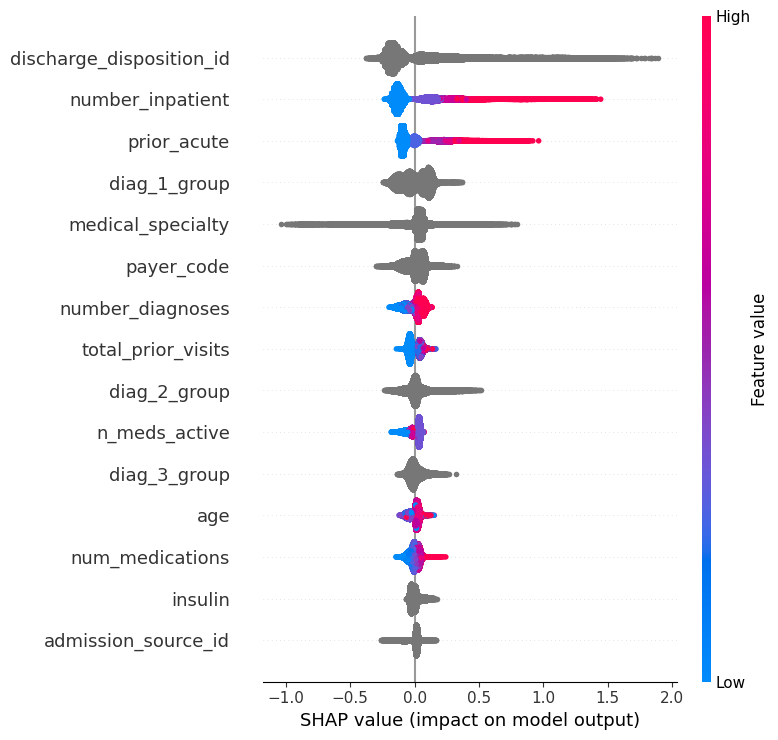

In [37]:
import shap

model = lightgbm_native(**LGBM_BEST_PARAMS)
model.fit(X2_cat, y2)

explainer = shap.TreeExplainer(model)
sv = explainer.shap_values(X2_cat)
# binary LGBM may return a list [neg, pos] or a single array depending on version
sv_pos = sv[1] if isinstance(sv, list) else sv

shap.summary_plot(sv_pos, X2_cat, max_display=15)

In [38]:
import numpy as np
imp = pd.Series(np.abs(sv_pos).mean(axis=0), index=X2_cat.columns).sort_values(ascending=False)
print(imp.head(15).round(4))

discharge_disposition_id    0.2018
number_inpatient            0.1713
prior_acute                 0.1085
diag_1_group                0.0835
medical_specialty           0.0773
payer_code                  0.0586
number_diagnoses            0.0515
total_prior_visits          0.0424
diag_2_group                0.0420
n_meds_active               0.0366
diag_3_group                0.0353
age                         0.0305
num_medications             0.0277
insulin                     0.0273
admission_source_id         0.0231
dtype: float64


In [40]:
from src.clean import TARGET

d = df_all2.copy()
d["pred"] = model.predict_proba(X2_cat)[:, 1]

print("Readmission rate by prior inpatient visits:")
print(d.groupby(d.number_inpatient.clip(upper=4))[TARGET].agg(["mean", "size"]).round(4))

print("\nReadmission rate by discharge destination:")
print(d.groupby("discharge_group")[TARGET].agg(["mean", "size"]).sort_values("mean", ascending=False).round(4))

print("\nDecile analysis:")
d["decile"] = pd.qcut(d.pred, 10, labels=False, duplicates="drop")
print(d.groupby("decile")[TARGET].agg(["mean", "size"]).round(4))

Readmission rate by prior inpatient visits:
                    mean   size
number_inpatient               
0                 0.0859  66245
1                 0.1325  18984
2                 0.1793   7300
3                 0.2103   3271
4                 0.3136   3543

Readmission rate by discharge destination:
                   mean   size
discharge_group               
Rehab            0.2770   1993
Other            0.2000     55
Facility         0.1898   3519
SNF              0.1466  14002
AMA              0.1445    623
HomeIV           0.1389    108
ICF              0.1276    815
HomeHealth       0.1270  12902
Unknown          0.1177   4680
Home             0.0930  60234
LongTerm         0.0728    412

Decile analysis:
          mean  size
decile              
0       0.0167  9935
1       0.0389  9934
2       0.0516  9934
3       0.0619  9934
4       0.0788  9935
5       0.0943  9934
6       0.1089  9934
7       0.1451  9934
8       0.1928  9934
9       0.3499  9935


In [41]:
d["pred_oof"] = oof2
d["decile_oof"] = pd.qcut(d.pred_oof, 10, labels=False, duplicates="drop")
print(d.groupby("decile_oof")[TARGET].agg(["mean", "size"]).round(4))

              mean  size
decile_oof              
0           0.0370  9935
1           0.0574  9934
2           0.0636  9934
3           0.0726  9934
4           0.0898  9935
5           0.1062  9934
6           0.1178  9934
7           0.1370  9934
8           0.1721  9934
9           0.2854  9935


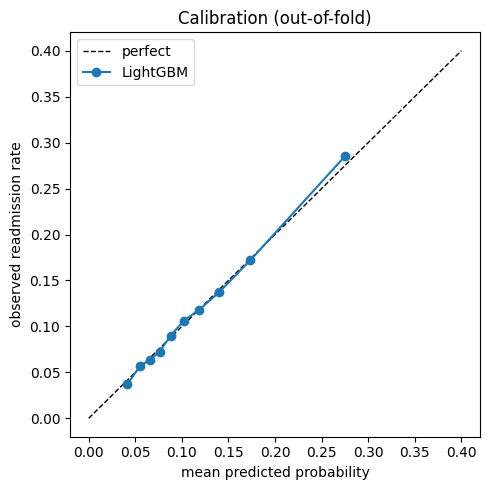

   predicted  observed
0     0.0415    0.0370
1     0.0556    0.0574
2     0.0658    0.0636
3     0.0761    0.0726
4     0.0879    0.0898
5     0.1018    0.1062
6     0.1182    0.1178
7     0.1398    0.1370
8     0.1736    0.1721
9     0.2751    0.2854


In [42]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y2, oof2, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 0.4], [0, 0.4], "k--", lw=1, label="perfect")
ax.plot(prob_pred, prob_true, "o-", label="LightGBM")
ax.set_xlabel("mean predicted probability")
ax.set_ylabel("observed readmission rate")
ax.set_title("Calibration (out-of-fold)")
ax.legend()
plt.tight_layout()
plt.show()

print(pd.DataFrame({"predicted": prob_pred, "observed": prob_true}).round(4))

In [43]:
from sklearn.metrics import roc_auc_score, average_precision_score

def subgroup_report(d, col, y_col=TARGET, score_col="pred_oof", min_n=200):
    rows = []
    for name, g in d.groupby(col, observed=True):
        if len(g) < min_n or g[y_col].nunique() < 2:
            continue
        rows.append({
            col: name,
            "n": len(g),
            "prevalence": g[y_col].mean(),
            "auroc": roc_auc_score(g[y_col], g[score_col]),
            "auprc": average_precision_score(g[y_col], g[score_col]),
            "mean_pred": g[score_col].mean(),
            "calib_gap": g[score_col].mean() - g[y_col].mean(),
        })
    return pd.DataFrame(rows).sort_values("n", ascending=False).round(4)

for col in ["race", "gender"]:
    print(f"\n=== {col} ===")
    print(subgroup_report(d, col).to_string(index=False))

d["age_band"] = pd.cut(d.age, [0, 40, 60, 75, 100],
                       labels=["<40", "40-60", "60-75", "75+"])
print("\n=== age_band ===")
print(subgroup_report(d, "age_band").to_string(index=False))


=== race ===
           race     n  prevalence  auroc  auprc  mean_pred  calib_gap
      Caucasian 74220      0.1153 0.6794 0.2409     0.1144    -0.0009
AfricanAmerican 18772      0.1145 0.6712 0.2245     0.1152     0.0007
        Missing  2234      0.0842 0.6509 0.1597     0.0893     0.0051
       Hispanic  2017      0.1051 0.7434 0.2909     0.1055     0.0004
          Other  1472      0.0978 0.6834 0.2192     0.1024     0.0046
          Asian   628      0.1035 0.7314 0.3159     0.0995    -0.0040

=== gender ===
gender     n  prevalence  auroc  auprc  mean_pred  calib_gap
Female 53454      0.1146 0.6820 0.2388     0.1153     0.0007
  Male 45886      0.1130 0.6764 0.2348     0.1114    -0.0016

=== age_band ===
age_band     n  prevalence  auroc  auprc  mean_pred  calib_gap
   60-75 47390      0.1171 0.6683 0.2308     0.1155    -0.0015
   40-60 26667      0.1009 0.7035 0.2441     0.1035     0.0026
     75+ 19023      0.1247 0.6283 0.2132     0.1242    -0.0005
     <40  6263      0.1122 

In [44]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from sklearn.calibration import calibration_curve

FIG = Path.cwd().parent / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

# 1. SHAP summary
shap.summary_plot(sv_pos, X2_cat, max_display=15, show=False)
plt.tight_layout()
plt.savefig(FIG / "shap_summary.png", dpi=150, bbox_inches="tight")
plt.close()

# 2. Calibration
prob_true, prob_pred = calibration_curve(y2, oof2, n_bins=10, strategy="quantile")
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot([0, 0.32], [0, 0.32], "k--", lw=1, label="perfect calibration")
ax.plot(prob_pred, prob_true, "o-", color="#1f77b4", label="LightGBM (out-of-fold)")
ax.set_xlabel("mean predicted probability")
ax.set_ylabel("observed readmission rate")
ax.set_title("Calibration, out-of-fold")
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "calibration.png", dpi=150)
plt.close()

# 3. Decile lift
dec = d.groupby("decile_oof")[TARGET].mean()
base = y2.mean()
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(dec.index, dec.values, color="#4c72b0")
ax.axhline(base, color="crimson", ls="--", lw=1.5, label=f"base rate ({base:.1%})")
ax.set_xlabel("risk decile (out-of-fold)")
ax.set_ylabel("observed 30-day readmission rate")
ax.set_title("Readmission rate by predicted risk decile")
ax.set_xticks(range(10))
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "decile_lift.png", dpi=150)
plt.close()

# 4. Subgroup AUROC by age band
ab = subgroup_report(d, "age_band")
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(ab["age_band"].astype(str), ab["auroc"], color="#55a868")
ax.axhline(0.6795, color="crimson", ls="--", lw=1.5, label="overall (0.680)")
ax.set_ylim(0.55, 0.80)
ax.set_ylabel("AUROC")
ax.set_xlabel("age band")
ax.set_title("Discrimination by age band")
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "auroc_by_age.png", dpi=150)
plt.close()

print(sorted(p.name for p in FIG.glob("*.png")))


['auroc_by_age.png', 'calibration.png', 'decile_lift.png', 'shap_summary.png']


In [45]:
print(f"top 3 share: {imp.head(3).sum() / imp.sum():.1%}")

top 3 share: 40.4%


In [46]:
raw = load_raw()
print((raw.readmitted == ">30").mean())

0.3492816854352141


In [47]:
df_all_check = clean(load_raw(), first_encounter_only=False, verbose=False)
print([df_all_check[c].nunique() for c in ["diag_1", "diag_2", "diag_3"]])

[716, 748, 787]


In [48]:
from src.icd9 import add_diagnosis_groups
g = add_diagnosis_groups(df_all_check)
print((g.diag_1_group == "Other").mean())

0.09310167802462177


In [49]:
from sklearn.model_selection import train_test_split as tts
from src.mlp import train_mlp
from src.evaluate import evaluate

Xa, Xb, ya, yb = tts(X2, y2, test_size=0.2, stratify=y2, random_state=42)
mlp, scores = train_mlp(Xa, ya, Xb, yb)
pd.Series(evaluate(yb, scores)).round(4)

epoch  1  val AUPRC 0.2212  *
epoch  2  val AUPRC 0.2244  *
epoch  3  val AUPRC 0.2296  *
epoch  4  val AUPRC 0.2301  *
epoch  5  val AUPRC 0.2324  *
epoch  6  val AUPRC 0.2321
epoch  7  val AUPRC 0.2319
epoch  8  val AUPRC 0.2351  *
epoch  9  val AUPRC 0.2342
epoch 10  val AUPRC 0.2337
epoch 11  val AUPRC 0.2337
epoch 12  val AUPRC 0.2347
epoch 13  val AUPRC 0.2336
early stop at epoch 13


auroc             0.6727
auprc             0.2351
auprc_baseline    0.1139
auprc_lift        2.0645
brier             0.0964
brier_baseline    0.1009
precision@10%     0.2793
lift@10%          2.4524
dtype: float64

In [1]:
from src.evaluate import precision_at_k
print(round(precision_at_k(y_train, oof), 4))

NameError: name 'y_train' is not defined

In [2]:
import pandas as pd
from sklearn.model_selection import cross_val_predict, StratifiedKFold

from src.load_data import load_raw
from src.clean import clean
from src.icd9 import add_diagnosis_groups
from src.features import prepare, split_xy, make_splits
from src.models import logistic_baseline
from src.evaluate import precision_at_k

df = prepare(add_diagnosis_groups(clean(load_raw(), verbose=False)))
X, y, _ = split_xy(df)
X_train, X_test, y_train, y_test = make_splits(X, y)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof = cross_val_predict(logistic_baseline(X_train), X_train, y_train,
                        cv=cv, method="predict_proba", n_jobs=-1)[:, 1]

print(round(precision_at_k(y_train, oof), 4))

0.2081


In [3]:
from sklearn.model_selection import StratifiedGroupKFold
from src.features import add_engineered_features
from src.evaluate import evaluate

df_all2 = prepare(add_engineered_features(
    add_diagnosis_groups(clean(load_raw(), first_encounter_only=False, verbose=False))
))
X2, y2, g2 = split_xy(df_all2)

gcv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
oof_lr_all = cross_val_predict(logistic_baseline(X2), X2, y2, cv=gcv,
                               groups=g2, method="predict_proba", n_jobs=-1)[:, 1]

pd.Series(evaluate(y2, oof_lr_all)).round(4)

auroc             0.6643
auprc             0.2154
auprc_baseline    0.1139
auprc_lift        1.8909
brier             0.0968
brier_baseline    0.1009
precision@10%     0.2641
lift@10%          2.3191
dtype: float64